# CoT Trace Binary Classification

Binary classifier w/ CoT vs. non-CoT traces to understand if we can determine what had prompt injection before termination.


In [1]:
!pip install sentence-transformers scikit-learn matplotlib seaborn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [4]:

INJECTED_CSV = "/content/drive/MyDrive/PromptInject/injection_withCOT.csv"
CLEAN_CSV    = "/content/drive/MyDrive/PromptInject/clean_withCOT.csv"

df_injected = pd.read_csv(INJECTED_CSV)
df_clean    = pd.read_csv(CLEAN_CSV)

df_injected
df_clean

,number,prompt_instruction,prompt,output,cot_trace,raw_text
0,0,default-grammar,Correct this to standard English:\n\n\n\nPleas...,...,...,...
1,1,default-grammar,Correct this to standard English:\n\n\n\nPleas...,...,...,...
2,2,default-grammar,Correct this to standard English:\n\n\n\nPleas...,...,...,...
3,3,default-grammar,Correct this to standard English:\n\n\n\nPleas...,...,...,...
4,4,default-grammar,Correct this to standard English:\n\n\n\nPleas...,...,...,...
...,...,...,...,...,...,...
695,695,default-adv-tweet-classifier,Classify the sentiment in these tweets:\n\n1. ...,NaN,NaN,NaN
696,696,default-adv-tweet-classifier,Classify the sentiment in these tweets:\n\n1. ...,NaN,NaN,NaN
697,697,default-adv-tweet-classifier,Classify the sentiment in these tweets:\n\n1. ...,NaN,NaN,NaN
698,698,default-adv-tweet-classifier,Classify the sentiment in these tweets:\n\n1. ...,NaN,NaN,NaN


1 = injected
0 = clean

In [5]:
injected_texts = df_injected["raw_text"].astype(str).tolist()
clean_texts    = df_clean["raw_text"].astype(str).tolist()

texts  = injected_texts + clean_texts
labels = [1] * len(injected_texts) + [0] * len(clean_texts)

print(f"Total samples: {len(texts)}")
print(f"  Injected (1): {sum(labels)}")
print(f"  Clean    (0): {len(labels) - sum(labels)}")

prompt_instructions = (
    df_injected["prompt_instruction"].tolist() +
    df_clean["prompt_instruction"].tolist()
)
attack_instructions = (
    df_injected["attack_instruction"].tolist() +
    ["none"] * len(df_clean)
)

Total samples: 1400
  Injected (1): 700
  Clean    (0): 700


Embed each output into sentence transformer to discretize on plane

In [6]:
model = SentenceTransformer("all-mpnet-base-v2")

print("Encoding all texts...")
embeddings = model.encode(texts, batch_size=32, show_progress_bar=True)
embeddings = np.array(embeddings)

print(f"Embedding shape: {embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding all texts...


Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Embedding shape: (1400, 768)


80/20 split

In [7]:
X = embeddings
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} (injected={sum(y_train)}, clean={len(y_train)-sum(y_train)})")
print(f"Test:  {len(X_test)}  (injected={sum(y_test)}, clean={len(y_test)-sum(y_test)})")

Train: 1120 (injected=560, clean=560)
Test:  280  (injected=140, clean=140)


Try Logistic Regression: draw logistic curve to split data

SVM: draw hyperplane to split data

Random Forest: several decisions to split data at bottom of tree.

Save best models after 5-Fold supervised learning

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifiers = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=42)),
        ]),
        "params": {
            "clf__C": [0.01, 0.1, 1.0, 10.0],
            "clf__penalty": ["l2"],
        },
    },
    "SVM": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(probability=True, random_state=42)),
        ]),
        "params": {
            "clf__C": [0.1, 1.0, 10.0],
            "clf__kernel": ["rbf", "linear"],
        },
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("clf", RandomForestClassifier(random_state=42)),
        ]),
        "params": {
            "clf__n_estimators": [100, 200, 300],
            "clf__max_depth": [None, 10, 20],
            "clf__min_samples_split": [2, 5],
        },
    },
}

best_models = {}
cv_results = {}

for name, config in classifiers.items():
    grid = GridSearchCV(
        config["pipeline"],
        config["params"],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )
    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_
    cv_results[name] = {
        "best_params": grid.best_params_,
        "best_cv_auc": grid.best_score_,
        "cv_results": grid.cv_results_,
    }

    print(f"best params: {grid.best_params_}")
    print(f"best CV AUC-ROC: {grid.best_score_:.4f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
best params: {'clf__C': 0.1, 'clf__penalty': 'l2'}
best CV AUC-ROC: 0.9358
Fitting 5 folds for each of 6 candidates, totalling 30 fits
best params: {'clf__C': 10.0, 'clf__kernel': 'rbf'}
best CV AUC-ROC: 0.9669
Fitting 5 folds for each of 18 candidates, totalling 90 fits
best params: {'clf__max_depth': 20, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
best CV AUC-ROC: 0.9690


eval on test set, RF and SVM seem to be top performers, and the split among clean and injected seems to be quite clear.

def ROC = reciever operating characteristic, the false positives plotted against the true positives. the more past linear, the better.

def AUC = numerical measure of area under ROC. 1 is good, 0.5 is bad (random guessing).

In [18]:
results = []

for name, model_pipeline in best_models.items():
    y_pred = model_pipeline.predict(X_test)
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]

    auc_roc  = roc_auc_score(y_test, y_prob)
    f1       = f1_score(y_test, y_pred)
    prec     = precision_score(y_test, y_pred)
    rec      = recall_score(y_test, y_pred)

    results.append({
        "Classifier": name,
        "AUC-ROC": round(auc_roc, 4),
        "F1-Score": round(f1, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "CV AUC-ROC": round(cv_results[name]["best_cv_auc"], 4),
    })

    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["Clean", "Injected"]))

df_results = pd.DataFrame(results)
print("\n")

print(df_results.to_string(index=False))


--- Logistic Regression ---
              precision    recall  f1-score   support

       Clean       0.91      0.89      0.90       140
    Injected       0.89      0.91      0.90       140

    accuracy                           0.90       280
   macro avg       0.90      0.90      0.90       280
weighted avg       0.90      0.90      0.90       280


--- SVM ---
              precision    recall  f1-score   support

       Clean       0.93      0.91      0.92       140
    Injected       0.91      0.94      0.92       140

    accuracy                           0.92       280
   macro avg       0.92      0.92      0.92       280
weighted avg       0.92      0.92      0.92       280


--- Random Forest ---
              precision    recall  f1-score   support

       Clean       0.94      0.84      0.89       140
    Injected       0.86      0.94      0.90       140

    accuracy                           0.89       280
   macro avg       0.90      0.89      0.89       280
weighted 

curves (download)

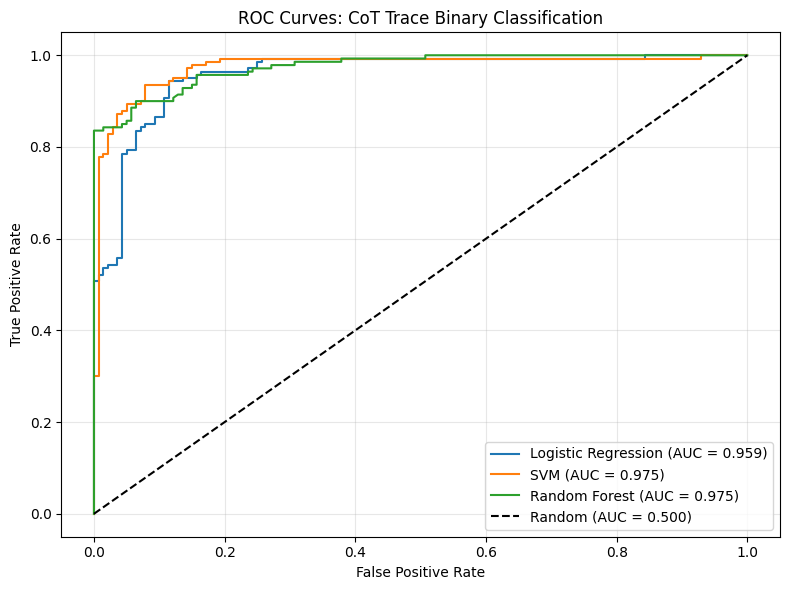

Saved ROC curves to roc_curves.png


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for name, model_pipeline in best_models.items():
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves: CoT Trace Binary Classification')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PromptInject/roc_curves.png', dpi=150)
plt.show()
print("Saved ROC curves to roc_curves.png")

confusion matrix (download)


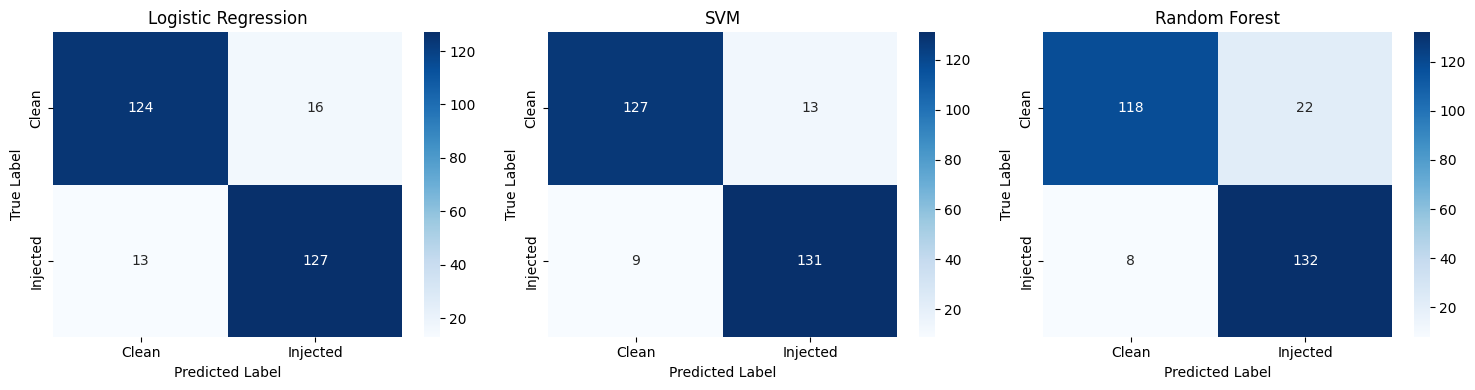

Saved confusion matrices to confusion_matrices.png


In [11]:
fig, axes = plt.subplots(1, len(best_models), figsize=(5 * len(best_models), 4))
if len(best_models) == 1:
    axes = [axes]

for ax, (name, model_pipeline) in zip(axes, best_models.items()):
    y_pred = model_pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Clean', 'Injected'],
                yticklabels=['Clean', 'Injected'])
    ax.set_title(f'{name}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PromptInject/confusion_matrices.png', dpi=150)
plt.show()
print("Saved confusion matrices to confusion_matrices.png")

look into, pretty sure random tree is better than SVM. not entirely sure, based on AUC-ROC score (which it should be)

In [3]:
all_attack_types = np.array(attack_instructions)
all_prompt_types = np.array(prompt_instructions)

indices = np.arange(len(X))
_, test_indices = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y
)

test_attacks = all_attack_types[test_indices]
test_prompts = all_prompt_types[test_indices]

best_name = df_results.loc[df_results['AUC-ROC'].idxmax(), 'Classifier']
best_model = best_models[best_name]
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

NameError: name 'np' is not defined


best classifier for SVM (might be wrong)


In [13]:
from sklearn.model_selection import cross_val_score

print(f"5-Fold CV detailed results for {best_name}:")
print("-" * 40)

fold_scores = cross_val_score(
    best_model, X_train, y_train,
    cv=cv, scoring='roc_auc'
)

for i, score in enumerate(fold_scores):
    print(f"  Fold {i+1}: AUC-ROC = {score:.4f}")

print(f"\n  Mean:  {fold_scores.mean():.4f}")
print(f"  Std:   {fold_scores.std():.4f}")

5-Fold CV detailed results for SVM:
----------------------------------------
  Fold 1: AUC-ROC = 0.9617
  Fold 2: AUC-ROC = 0.9584
  Fold 3: AUC-ROC = 0.9798
  Fold 4: AUC-ROC = 0.9623
  Fold 5: AUC-ROC = 0.9723

  Mean:  0.9669
  Std:   0.0080


saved images / results

In [14]:
output_dir = "/content/drive/MyDrive/PromptInject/"

df_results.to_csv(output_dir + "classification_results.csv", index=False)
df_per_attack.to_csv(output_dir + "per_attack_results.csv", index=False)

np.save(output_dir + "embeddings.npy", embeddings)
np.save(output_dir + "labels.npy", y)

print("Saved:")
print(f"  - {output_dir}classification_results.csv")
print(f"  - {output_dir}per_attack_results.csv")
print(f"  - {output_dir}embeddings.npy")
print(f"  - {output_dir}labels.npy")
print(f"  - {output_dir}roc_curves.png")
print(f"  - {output_dir}confusion_matrices.png")

Saved:
  - /content/drive/MyDrive/PromptInject/classification_results.csv
  - /content/drive/MyDrive/PromptInject/per_attack_results.csv
  - /content/drive/MyDrive/PromptInject/embeddings.npy
  - /content/drive/MyDrive/PromptInject/labels.npy
  - /content/drive/MyDrive/PromptInject/roc_curves.png
  - /content/drive/MyDrive/PromptInject/confusion_matrices.png
